In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score

In [19]:
dataset = pd.read_csv('insurance.csv')

In [20]:
dataset.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
dataset['region'].nunique()

4

In [22]:
dataset['region'].value_counts(normalize=True)*100

southeast    27.204783
southwest    24.289985
northwest    24.289985
northeast    24.215247
Name: region, dtype: float64

In [23]:
sex_dummy = pd.get_dummies(dataset['sex'])
sex_dummy.head(5)

,female,male
0,1,0
1,0,1
2,0,1
3,0,1
4,0,1


In [24]:
dataset = pd.concat([dataset.iloc[:,0],sex_dummy,dataset.iloc[:,2:]], axis=1)
dataset.head(5)

,age,female,male,bmi,children,smoker,region,charges
0,19,1,0,27.900,0,yes,southwest,16884.92400
1,18,0,1,33.770,1,no,southeast,1725.55230
2,28,0,1,33.000,3,no,southeast,4449.46200
3,33,0,1,22.705,0,no,northwest,21984.47061
4,32,0,1,28.880,0,no,northwest,3866.85520


In [25]:
smoker_dummy = pd.get_dummies(dataset['smoker'])
region_dummy = pd.get_dummies(dataset['region'])

In [26]:
dataset = pd.concat([dataset.iloc[:,0:5],smoker_dummy,region_dummy,dataset.iloc[:,7:]], axis=1)
dataset.head(5)

,age,female,male,bmi,children,no,yes,northeast,northwest,southeast,southwest,charges
0,19,1,0,27.900,0,0,1,0,0,0,1,16884.92400
1,18,0,1,33.770,1,1,0,0,0,1,0,1725.55230
2,28,0,1,33.000,3,1,0,0,0,1,0,4449.46200
3,33,0,1,22.705,0,1,0,0,1,0,0,21984.47061
4,32,0,1,28.880,0,1,0,0,1,0,0,3866.85520


In [27]:
dataset = dataset.drop(columns=['male','no'])
dataset.head(3)

,age,female,bmi,children,yes,northeast,northwest,southeast,southwest,charges
0,19,1,27.90,0,1,0,0,0,1,16884.9240
1,18,0,33.77,1,0,0,0,1,0,1725.5523
2,28,0,33.00,3,0,0,0,1,0,4449.4620


In [28]:
dataset = dataset.rename(columns={'yes': 'smoker', 'female': 'sex'})
dataset.head(1)

,age,sex,bmi,children,smoker,northeast,northwest,southeast,southwest,charges
0,19,1,27.9,0,1,0,0,0,1,16884.924


In [29]:
train_data,test_data = train_test_split(dataset,test_size=0.2)

In [30]:
train_data.shape

(1070, 10)

In [31]:
test_data.shape

(268, 10)

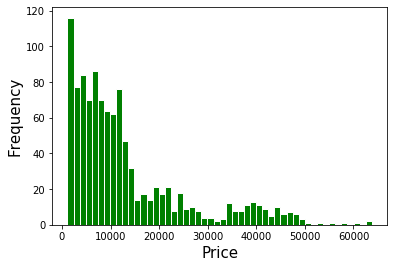

In [32]:
plt.hist(train_data['charges'], bins=50, color='green', edgecolor='white')
plt.xlabel('Price', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.show()

In [35]:
median_charges_by_sex = pd.DataFrame(train_data.groupby('sex')['charges'].median())
median_charges_by_sex = median_charges_by_sex.rename(index={0:'male', 1:'female'})
median_charges_by_sex

,charges
sex,
male,9504.31030
female,9095.06825


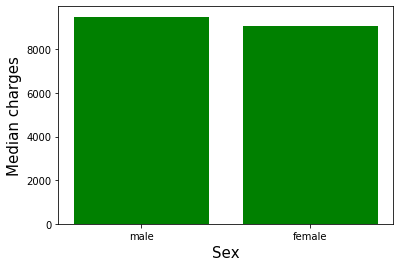

In [36]:
plt.bar(range(0,len(median_charges_by_sex)), median_charges_by_sex['charges'], color='green')
plt.xticks(range(0,len(median_charges_by_sex)), median_charges_by_sex.index)
plt.xlabel('Sex', fontsize=15)
plt.ylabel('Median charges', fontsize=15)
plt.show()

In [39]:
reg_model = LinearRegression()
reg_model.fit(train_data.iloc[:,0:9],train_data.iloc[:,9])

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [40]:
reg_model.coef_

array([  252.83787364,   300.40399397,   330.60058708,   583.94366971,
       24081.71948101,   664.46150502,   -58.95016102,  -240.64591485,
        -364.86542914])

In [41]:
test_data_pred = reg_model.predict(test_data.iloc[:,0:9])

In [43]:
r2_score(test_data.iloc[:,9],test_data_pred)

0.740514116791445

In [44]:
mean_squared_error(test_data.iloc[:,9],test_data_pred)

38660400.166957244

In [49]:
test_data.iloc[70,9]

14235.072

In [50]:
test_data_pred[70]

16958.69808554511

In [70]:
def poly_regression(degree,x_data,y_data):
    poly_fet = PolynomialFeatures(degree=degree)
    x_poly = poly_fet.fit_transform(x_data)
    poly_reg = LinearRegression()
    poly_reg.fit(x_poly,y_data)
    return poly_reg
def poly_reg_predict(degree,poly_reg,test_data):
    poly_fet = PolynomialFeatures(degree=degree)
    pred = poly_reg.predict(poly_fet.fit_transform(test_data))
    return pred

In [77]:
poly_reg_deg_2 = poly_regression(2,train_data.iloc[:,0:9],train_data.iloc[:,9])
test_predict_deg_2 = poly_reg_predict(2,poly_reg_deg_2,test_data.iloc[:,0:9])
print(r2_score(test_data.iloc[:,9],test_predict_deg_2))
print(mean_squared_error(test_data.iloc[:,9],test_predict_deg_2))

0.8457112277095493
22987245.411047127


In [78]:
poly_reg_deg_3 = poly_regression(3,train_data.iloc[:,0:9],train_data.iloc[:,9])
test_predict_deg_3 = poly_reg_predict(3,poly_reg_deg_3,test_data.iloc[:,0:9])
print(r2_score(test_data.iloc[:,9],test_predict_deg_3))
print(mean_squared_error(test_data.iloc[:,9],test_predict_deg_3))

0.8124980231587169
27935629.35735289


-1.3240489044289094